# inverse_design_multi_point_example.ipynb
The goal of this Notebook is to perform an airfoil inverse design with a multi-point objective

## 1. Import libraries and initialize settings

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [ ]:
from pathlib import Path
import sys
import os
# 
PROJECT_ROOT = Path("path here").resolve()
ADAPT_ROOT = PROJECT_ROOT / "ADAPT"

sys.path.insert(0, str(PROJECT_ROOT))
# os.chdir(PROJECT_ROOT)

In [3]:
# ---- import from existing libs ----
import torch 
import pickle
from matplotlib import pyplot as plt      
import gpytorch 
from pathlib import Path

# ---- import relevant functions from the ADAPT suite ---- 
from ADAPT import adapt, visualize 
from ADAPT.utils import initialize_devices, initialize_plot_settings, n_to_device
from ADAPT.geometry import lam_pca_transformer 
from ADAPT.design import inverse

# ---- Initialize settings ----
# Set to float64 
torch.set_default_dtype(torch.float64) 

# We will run on GPU 0 
output_device = initialize_devices(use_gpu=True, gpu_id=0)

# This initializes plot settings that I like
initialize_plot_settings()

[DEVICE] Planning to run on GPU 0


## 2. Set up inverse designer

In [11]:
# Construct evaluation model  
class large_airfoil_model(inverse.evaluation_model):
    def __init__(self, lam_model):
        super().__init__(lam_model)   
        # using LAM model requires PCA_transformer
        self.pca_transformer = lam_pca_transformer(lam_model.output_device)
        self.output_device = self.model.output_device 
        
    def predict(self, candidate_design:inverse.airfoil_design_input, sample_tensor:torch.Tensor, get_grad=True):
        # Assemble LAM input tensor from a sample in the PC space 
        assert len(candidate_design.alpha) == len(candidate_design.mach), "Number of target alphas and Mach numbers must be the same."
        candidate_tensor = [] 

        for target_alpha, target_mach in zip(candidate_design.alpha, candidate_design.mach):  
            candidate_tensor_ = self.pca_transformer.assemble_lam_tensor_from_pcs(
                sample_tensor, 
                target_alpha, 
                target_mach, 
                200,
                normalize=True
                ).to(self.output_device)   
            candidate_tensor.append(candidate_tensor_)
        candidate_tensor = torch.cat(candidate_tensor, dim=0) 
        
        # Predict using the LAM 
        model_output = self.model.predict(candidate_tensor, get_coeff=False, get_grad=get_grad)

        if get_grad: 
            return model_output
        else: 
            return model_output['cp_distribution']
     
# ---- Initialize LAM ADAPT ----
model, _ = adapt.unpack_model(model_version='pca', output_device=output_device, verbose=False) # load in the model 
model.load_weights(_)
dummy = adapt.input_data('NACA 0012', 0.0, 0.0, 200, output_device=output_device, model_version='pca')
_ = model.predict(dummy, 
                  get_coeff=False, 
                  get_grad=False)['cp_distribution'] # this dummy pass fully initializes the model; is essential

# ---- Initialize PCA transformer ----
# Allows for easy conversion between design space (PC space) and physical coordinates 
pca_transformer = lam_pca_transformer(output_device)

# ---- Load in desired test case ----
with open(Path().resolve() / 'testcase1_SC1095.pkl', "rb") as file:
    test_case = pickle.load(file, )    

target_cps = []
print('Running test case 1')
target_alphas =[6.2, 6.2, 6.2]
target_machs  =[0.40, 0.6, 0.81,]
mu, cov = [], []
for a, m in zip(target_alphas, target_machs): 
    target_tensor_ = pca_transformer.assemble_lam_tensor_from_pcs(
                    test_case['target_af'].to(output_device) , 
                    a, 
                    m, 
                    200,
                    normalize=True
                    ).to(output_device)   
    model_output = model.predict(target_tensor_, get_coeff=False, get_grad=False)['cp_distribution']
    xc_ = (dummy.assemble_tensor()[:, -2] + 1) /2  
    target_covar = torch.eye(model_output.covariance_matrix.shape[0], device=model_output.covariance_matrix.device) * 0.02**2
    target_cps.append(gpytorch.distributions.MultivariateNormal(mean=model_output.mean, 
                                                                covariance_matrix=target_covar))


# ---- Define an initial airfoil geometry ---- 
# These are the coordinates of the NACA 0012 airfoil in the PC space
initial_guess = torch.tensor([-0.0814, -0.3764, -0.1992,  0.1521,  0.0569,  
                              0.3042, -0.1685, -0.0229, 0.2169,  0.0393, 
                              -0.0023, -0.0827, -0.0960, -0.0170,  0.0750], requires_grad=True).to(output_device)


# ---- Create design input file ----
input_file = inverse.airfoil_design_input(
    # design conditions
    alpha=target_alphas,
    mach=target_machs,
    
    # Initialize
    initial_design=initial_guess,
    
    # Active space settings 
    num_active_dims='auto',
    num_gradient_samples = 1000, 

    # Set targets
    target_cp=target_cps,
    target_cl=None, 
    target_cm=None, 
    target_cd=None, 
    target_design=None, # this is used for comparison
    
    # Transformations needed bn physical and design space 
    pca_transformer=pca_transformer,
    
    tolerance=5e-4, 
)

# ---- Create an instance of the probabilstic designer ----
airfoil_designer = inverse.probabilistic_designer(evaluation_model=large_airfoil_model(model),
                                                      user_input=input_file,
                                                      max_iters=2000,
                                                      verbose=True
                                                      )


Running test case 1


## Run inverse design algorithm
By calling _run_design()_, we can begin the inverse design algorithm. The design process carries out Stochastic Variational Inference from a prior design space (defined about the initial airfoil), and finds a much narrower _posterior_ design space. In the posterior design space, active-inactive space analysis is performed. The inactive space of the posterior design space is considered to be the final airfoil design + tolerance bounds. This procedure is the same compared to the single point design, although it will be more computationally intensive

Test case 1:
L 
[457.84,   88.82] 0 
[463.5025, 88.0498 552] 0 
[463.1715, 89.7469, loss 531] 1
[458.8726, 88.43  loss:533] 2
[462.2577, 89.316 loss:567] 3

545

In [12]:
import pyro
pyro.set_rng_seed(4)
design, history = airfoil_designer.run_design(num_particles=4)

Narrowing down the design space via SVI...


Iterations:   0%|          | 0/2000 [00:00<?, ?it/s]

SVI runtime 831.4806895256042
Determining airfoil tolerances from the provided design space...
    Approximating C from 1000 samples...
        Approximating C_i with respect to C_p...
    Partitioning C into active and inactive space...
    A total of 1 active dimensions found...
    Characterizing the inactive space...
Tol covar runtime 174.00169563293457
Approximating design airfoil's aerodynamic characteristics using Gaussian Mixtures...
Dlete below 
Finished!


In [ ]:
save_dict = {
    'design':design
}

# torch.save(save_dict, './airfoil_design.pt') 

## Check the finalized design and its aerodynamic characteristics 
From the output distributions, we obtain the mean, standard deviations and format them in a way that is convenient for formatting. This can be done via using _'helper_*_plotting()'_ functions

In [13]:
# design = torch.load('./airfoil_design.pt', weights_only=False)['design']

# Initial airfoil
# ini_af = inverse.helper_airfoil_plotting(design, manual_distrib=design.initial_design, return_dict=True) 

# Designed airfoil and its Cp distribution  
dgn_af = inverse.helper_airfoil_plotting(design, return_dict=True)
dgn_cp = inverse.helper_cp_plotting(design.design_cp_distrib, return_dict=True, num_samples=100)

# Target airfoil and its Cp distribution 
tgt_af = inverse.helper_airfoil_plotting(design, design.target_design, return_dict=True)
tgt_cp = inverse.helper_cp_plotting(design.target_cp, return_dict=True, num_samples=100)

### Designed airfoil geometry

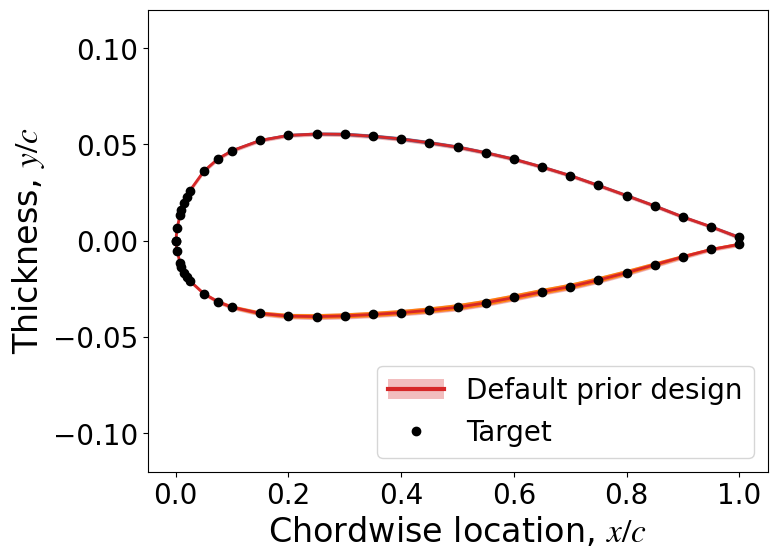

In [14]:
f, ax = plt.subplots(1,1, figsize=(8,6))
f, ax, leg = visualize.plot_airfoil(
    f, ax,
    plotting_elements = [dgn_af,
                         tgt_af],

    kwargs_list = [[{'color':'tab:red', 'linewidth':2.0}, {'color':'tab:red', 'alpha':0.3}, {}],
                   [{'color':'k', 'marker':'o', 'linestyle':'None'}, {}],],

    legend_handle = [
        ("tab:red", "tab:red", "-", "None", 1.0),
        ("None", "k", "None", "o", 1.0),
    ],

    legend_labels = ['Default prior design', 
                     'Target']
)

ax.set_ylim([-0.12, 0.12])
leg.set_loc('lower right')
plt.show()

### Designed airfoil's $C_p$ distribution

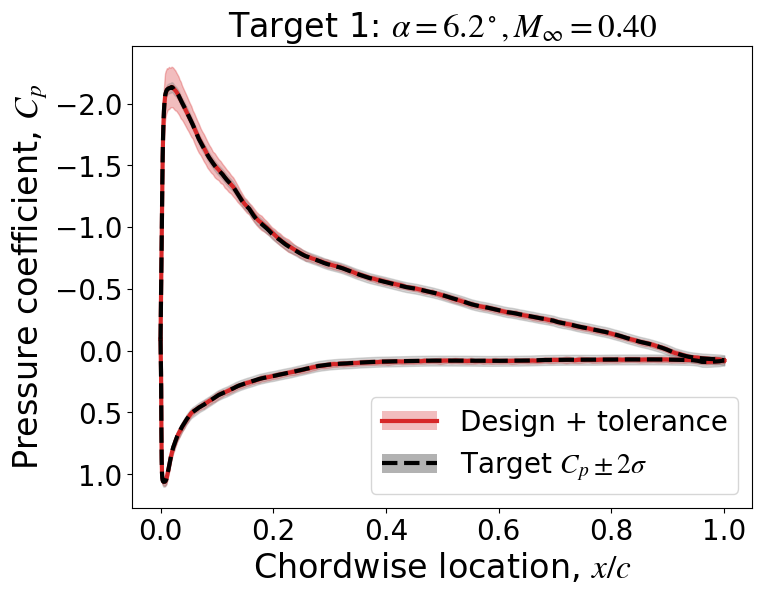

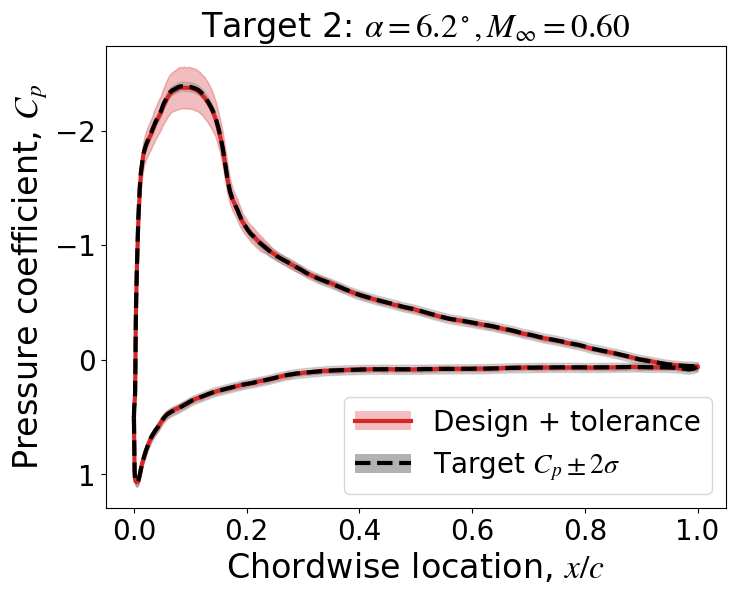

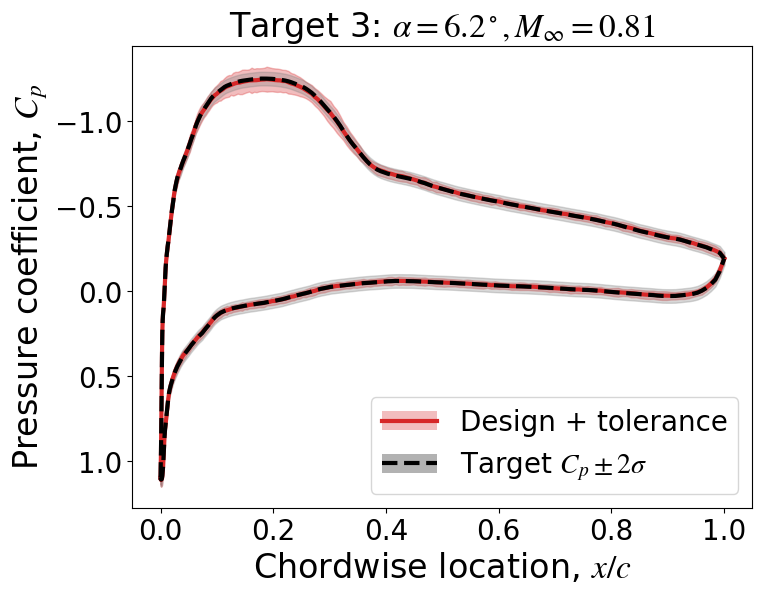

In [15]:
f, ax = plt.subplots(1,1, figsize=(8,6))
f, ax, leg = visualize.plot_cp(
    f, ax,
    plotting_elements = [dgn_cp[0], 
                         tgt_cp[0]],
    
    kwargs_list = [[{'color':'tab:red', 'linewidth':3.0}, {'color':'tab:red', 'alpha':0.3}],
                   [{'color':'k', 'linestyle':'--'}, {'color':'gray', 'alpha':0.3}],],

    legend_handle = [ 
        ("tab:red", "tab:red", "-", "None", 1.0),  
        ("k", "k", "--", "None", 1.0),
    ],
    
    legend_labels = ['Design + tolerance', 
                     'Target $C_p \pm 2\sigma$']
) 
leg.set_loc('lower right')
ax.set_title(r'Target 1: $\alpha = 6.2^\circ, M_\infty = 0.40$', fontsize=24) 
plt.show()

f, ax = plt.subplots(1,1, figsize=(8,6))
f, ax, leg = visualize.plot_cp(
    f, ax,
    plotting_elements = [dgn_cp[1], 
                         tgt_cp[1]],
    
    kwargs_list = [[{'color':'tab:red', 'linewidth':3.0}, {'color':'tab:red', 'alpha':0.3}],
                   [{'color':'k', 'linestyle':'--'}, {'color':'gray', 'alpha':0.3}],],

    legend_handle = [ 
        ("tab:red", "tab:red", "-", "None", 1.0),  
        ("k", "k", "--", "None", 1.0),
    ],
    
    legend_labels = ['Design + tolerance', 
                     'Target $C_p \pm 2\sigma$']
) 
leg.set_loc('lower right') 
ax.set_title(r'Target 2: $\alpha = 6.2^\circ, M_\infty = 0.60$', fontsize=24) 
plt.show()

f, ax = plt.subplots(1,1, figsize=(8,6))
f, ax, leg = visualize.plot_cp(
    f, ax,
    plotting_elements = [dgn_cp[2], 
                         tgt_cp[2]],
    
    kwargs_list = [[{'color':'tab:red', 'linewidth':3.0}, {'color':'tab:red', 'alpha':0.3}],
                   [{'color':'k', 'linestyle':'--'}, {'color':'gray', 'alpha':0.3}],],

    legend_handle = [ 
        ("tab:red", "tab:red", "-", "None", 1.0),  
        ("k", "k", "--", "None", 1.0),
    ],
    
    legend_labels = ['Design + tolerance', 
                     'Target $C_p \pm 2\sigma$']
) 
leg.set_loc('lower right') 
ax.set_title(r'Target 3: $\alpha = 6.2^\circ, M_\infty = 0.81$', fontsize=24) 
plt.show()

### Designed airfoil's aerodynamic force and moment coefficients: $c_l$, $c_m$, and $c_d$

In [16]:
coeff_str = ['cl', 'cm', 'cd']
coeff_list = [design.design_cl_distrib, design.design_cm_distrib, design.design_cd_distrib]
coeff_list_tgt = [n_to_device(test_case['target_cl'], 'cpu'), 
                  n_to_device(test_case['target_cm'], 'cpu'), 
                  n_to_device(test_case['target_cd'], 'cpu')]

print('Design: ')
for i, coeff in enumerate(coeff_list):
    _m, _s = inverse.sample_from_distrib(coeff)
    print(f'    {coeff_str[i]} ~ N({_m}, {2*_s})')
    
print('Target: ')
for i, coeff in enumerate(coeff_list_tgt):
    _m, _s = inverse.sample_from_distrib(coeff)
    print(f'    {coeff_str[i]} ~ N({_m}, {2*_s})')


Design: 
    cl ~ N([0.74364922 0.83918128 0.70339719], [0.01791356 0.02670995 0.01451276])
    cm ~ N([-0.00884362  0.00421113 -0.08019753], [0.00411075 0.00466248 0.00361323])
    cd ~ N([0.02303403 0.04121495 0.09738898], [0.00461308 0.00344693 0.00171736])
Target: 
    cl ~ N(0.8111111917977645, 0.0044422157230445325)
    cm ~ N(0.0039709411708485215, 0.0018265911282793904)
    cd ~ N(-0.008128796137014274, 0.0008194885831346184)
